## 1. Veri setini yükleyin ve ilk 10 satırı ile son 10 satırını ekrana yazdırın.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/e_ticaret_veri_seti.csv")

## 2. Veri setinin satır sayısını, sütun sayısını ve tüm sütun isimlerini ekrana yazdırın.


In [ ]:
print(f"Veri setinin satır sayısı: {df.shape[0]}")
print("-----------------------------------")
print(f"Veri setinin sütun sayısı: {df.shape[1]}")
print("-----------------------------------")
print("Tüm sütun isimleri:")
cols = df.columns.tolist()
for i,col in enumerate(cols,start=1):
  print(f"{i}. {col}")
# print(f"Tüm sütun isimleri: {cols}")

Veri setinin satır sayısı: 1428
-----------------------------------
Veri setinin sütun sayısı: 18
-----------------------------------
Tüm sütun isimleri:
1. siparis_id
2. musteri_id
3. siparis_tarihi
4. sehir
5. bolge
6. kategori
7. urun_adi
8. adet
9. birim_fiyat
10. indirim_orani
11. kargo_ucreti
12. odeme_turu
13. musteri_tipi
14. teslimat_gunu
15. musteri_puani
16. iade_durumu
17. kar_marji_orani
18. toplam_tutar


## 3. ``info()`` ve ``describe()`` çıktılarını alın. Ardından veri setindeki sayısal sütunları ve kategorik sütunları ayrı ayrı listeleyin.


In [ ]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1428 entries, 0 to 1427
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   siparis_id       1428 non-null   object 
 1   musteri_id       1428 non-null   object 
 2   siparis_tarihi   1428 non-null   object 
 3   sehir            1403 non-null   object 
 4   bolge            1428 non-null   object 
 5   kategori         1428 non-null   object 
 6   urun_adi         1428 non-null   object 
 7   adet             1428 non-null   int64  
 8   birim_fiyat      1428 non-null   float64
 9   indirim_orani    1412 non-null   float64
 10  kargo_ucreti     1428 non-null   float64
 11  odeme_turu       1393 non-null   object 
 12  musteri_tipi     1386 non-null   object 
 13  teslimat_gunu    1400 non-null   float64
 14  musteri_puani    1372 non-null   float64
 15  iade_durumu      1428 non-null   object 
 16  kar_marji_orani  1428 non-null   float64
 17  toplam_tutar  

In [ ]:
# float64(7), int64(1) -> 8 numeric sutun
sayisal_sutunlar = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Nümerik Sütunlar:")
for i,col in enumerate(sayisal_sutunlar,start=1):
  print(f"{i}. {col}")

Nümerik Sütunlar:
1. adet
2. birim_fiyat
3. indirim_orani
4. kargo_ucreti
5. teslimat_gunu
6. musteri_puani
7. kar_marji_orani
8. toplam_tutar


In [ ]:
kategorik_sutunlar = df.select_dtypes(include=['object']).columns.tolist()
print("Kategorik Sütunlar:")
for i,col in enumerate(kategorik_sutunlar,start=1):
  print(f"{i}. {col}")

Kategorik Sütunlar:
1. siparis_id
2. musteri_id
3. siparis_tarihi
4. sehir
5. bolge
6. kategori
7. urun_adi
8. odeme_turu
9. musteri_tipi
10. iade_durumu


In [ ]:
print(df.describe())

              adet   birim_fiyat  indirim_orani  kargo_ucreti  teslimat_gunu  \
count  1428.000000   1428.000000    1412.000000   1428.000000    1400.000000   
mean      2.136555    658.477654       0.052054     39.725140       3.370714   
std       2.015770   1042.414639       0.060115     14.185017       1.825990   
min       1.000000     93.110000       0.000000      0.000000       1.000000   
25%       1.000000    199.185000       0.000000     29.900000       2.000000   
50%       2.000000    287.120000       0.050000     39.900000       3.000000   
75%       3.000000    819.177500       0.100000     49.900000       4.000000   
max      38.000000  18145.230000       0.200000     59.900000      31.000000   

       musteri_puani  kar_marji_orani  toplam_tutar  
count    1372.000000      1428.000000   1428.000000  
mean        4.002187         0.302799   1370.590336  
std         1.096707         0.069795   2961.689500  
min         0.000000         0.180000     89.680000  
25%      

## 4. Her sütundaki eksik değer sayısını hesaplayın. Sonra eksik veri oranlarını yüzde olarak çıkarın ve eksik veri oranı en yüksek 5 sütunu yazdırın.

In [ ]:
missing_vals = df.isnull().sum()
print(f"Toplam Eksik Değer Sayısı: {missing_vals.sum()}")
print("Büyükten Küçüğe Eksik Değer Sayıları: ")
missing_vals[missing_vals > 0].sort_values(ascending=False)

Toplam Eksik Değer Sayısı: 202
Büyükten Küçüğe Eksik Değer Sayıları: 


,0
musteri_puani,56
musteri_tipi,42
odeme_turu,35
teslimat_gunu,28
sehir,25
indirim_orani,16


In [ ]:
eksik_veri_orani = round((df.isnull().sum() / len(df))*100,2)
print(f"Eksik Veri Oranı En Yüksek 5 Sütun (%):\n{eksik_veri_orani[eksik_veri_orani>0].sort_values(ascending=False).head()}%")

Eksik Veri Oranı En Yüksek 5 Sütun (%):
musteri_puani    3.92
musteri_tipi     2.94
odeme_turu       2.45
teslimat_gunu    1.96
sehir            1.75
dtype: float64%


## 5. En az bir eksik değer içeren satırları filtreleyin ve bu satırlardan ilk 20 tanesini ekrana yazdırın.


In [ ]:
print("En az 1 eksik değer içeren ilk 20 satır:")
df[df.isnull().any(axis=1)].head(20)

En az 1 eksik değer içeren ilk 20 satır:


,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
19,SIP100677,MUS1148,2024-07-11 16:24:00,Adana,Akdeniz,Spor,Dambıl Seti,4,1517.65,0.00,29.9,Kapıda Ödeme,Mevcut,3.0,NaN,Hayır,0.311,6100.50
33,SIP101126,MUS1406,2024-09-11 20:05:00,Mersin,Akdeniz,Elektronik,Bluetooth Hoparlör,1,1159.89,0.10,39.9,Kredi Kartı,NaN,2.0,4.0,Hayır,0.204,1083.80
50,SIP101040,MUS1386,2025-04-01 09:30:00,Trabzon,Karadeniz,Spor,Dambıl Seti,1,1554.15,0.00,49.9,Banka Kartı,NaN,4.0,5.0,Hayır,0.217,1604.05
60,SIP100890,MUS1271,2024-11-07 19:47:00,İzmir,Ege,Kitap,Girişimcilik,4,216.38,NaN,49.9,Kredi Kartı,Yeni,1.0,3.0,Hayır,0.199,915.42
61,SIP101317,MUS1060,2024-09-05 20:49:00,NaN,Akdeniz,Ev ve Yaşam,Saklama Kutusu,1,233.63,0.10,29.9,Dijital Cüzdan,Yeni,5.0,2.0,Hayır,0.385,240.17
70,SIP100715,MUS1033,2024-11-10 21:50:00,İstanbul,Marmara,Ev ve Yaşam,Termos,1,552.05,0.00,39.9,NaN,Mevcut,2.0,3.0,Hayır,0.185,591.95
82,SIP100807,MUS1431,2025-01-07 14:12:00,Ankara,İç Anadolu,Kozmetik,Güneş Kremi,1,451.28,0.00,49.9,Kredi Kartı,NaN,4.0,5.0,Hayır,0.315,501.18
84,SIP100679,MUS1310,2024-05-20 18:51:00,İzmir,Ege,Ev ve Yaşam,Termos,2,477.62,0.00,49.9,Kredi Kartı,Mevcut,NaN,4.0,Hayır,0.323,1005.14
86,SIP101071,MUS1131,2024-09-18 12:24:00,NaN,İç Anadolu,Elektronik,Powerbank,1,816.74,0.00,39.9,Banka Kartı,Yeni,3.0,5.0,Hayır,0.301,856.64
92,SIP101366,MUS1347,2025-03-04 14:00:00,Bursa,Marmara,Ev ve Yaşam,Organizer,1,272.40,0.00,29.9,Kredi Kartı,Mevcut,1.0,NaN,Hayır,0.212,302.30


## 6. ``indirim_orani`` ve ``musteri_puani`` sütunlarındaki eksik değerleri medyan ile doldurun. Doldurmadan önce ve sonra bu iki sütundaki eksik değer sayılarını karşılaştırın.

In [ ]:
print(f"indirim_orani sütunundaki eksik değer sayısı: {df['indirim_orani'].isnull().sum()}")
print(f"musteri_puani sütunundaki eksik değer sayısı: {df['musteri_puani'].isnull().sum()}")

indirim_oran_medyan = df["indirim_orani"].median()
musteri_puani_medyan = df["musteri_puani"].median()

df["indirim_orani"] = df["indirim_orani"].fillna(indirim_oran_medyan)
df["musteri_puani"] = df["musteri_puani"].fillna(musteri_puani_medyan)
print("--------------------------------------------------")
print("Medyan değer ile NaN değerler dolduruldu. Kontrol ediliyor:")
print("--------------------------------------------------")
print(f"indirim_orani sütunundaki eksik değer sayısı: {df['indirim_orani'].isnull().sum()}")
print(f"musteri_puani sütunundaki eksik değer sayısı: {df['musteri_puani'].isnull().sum()}")


indirim_orani sütunundaki eksik değer sayısı: 16
musteri_puani sütunundaki eksik değer sayısı: 56
--------------------------------------------------
Medyan değer ile NaN değerler dolduruldu. Kontrol ediliyor:
--------------------------------------------------
indirim_orani sütunundaki eksik değer sayısı: 0
musteri_puani sütunundaki eksik değer sayısı: 0


## 7. ``odeme_turu`` ve ``musteri_tipi`` sütunlarındaki eksik değerleri mod ile doldurun. Daha sonra bu sütunlarda eksik değer kalıp kalmadığını kontrol edin.

In [ ]:
print(f"odeme_turu sütunundaki eksik değer sayısı: {df['odeme_turu'].isnull().sum()}")
print(f"musteri_tipi sütunundaki eksik değer sayısı: {df['musteri_tipi'].isnull().sum()}")

odeme_turu_mod = df["indirim_orani"].mode()[0]
musteri_tipi_mod = df["musteri_tipi"].mode()[0]

df["odeme_turu"] = df["odeme_turu"].fillna(odeme_turu_mod)
df["musteri_tipi"] = df["musteri_tipi"].fillna(musteri_tipi_mod)
print("--------------------------------------------------")
print("NaN değerler en çok tekrar eden değer ile dolduruldu. Kontrol ediliyor:")
print("--------------------------------------------------")
print(f"odeme_turu sütunundaki eksik değer sayısı: {df['odeme_turu'].isnull().sum()}")
print(f"musteri_tipi sütunundaki eksik değer sayısı: {df['musteri_tipi'].isnull().sum()}")

odeme_turu sütunundaki eksik değer sayısı: 35
musteri_tipi sütunundaki eksik değer sayısı: 42
--------------------------------------------------
NaN değerler en çok tekrar eden değer ile dolduruldu. Kontrol ediliyor:
--------------------------------------------------
odeme_turu sütunundaki eksik değer sayısı: 0
musteri_tipi sütunundaki eksik değer sayısı: 0


## 8. ``siparis_tarihi`` sütununu ``datetime`` tipine dönüştürün. Ardından bu sütundan ``siparis_yili``, ``siparis_ayi``, ``siparis_gunu`` ve ``haftanin_gunu`` adında 4 yeni sütun üretin ve ilk 10 satırını gösterin.

In [ ]:
df["siparis_tarihi"] = pd.to_datetime(df["siparis_tarihi"])

df["siparis_yili"] = df["siparis_tarihi"].dt.year
df["siparis_ayi"] = df["siparis_tarihi"].dt.month
df["siparis_gunu"] = df["siparis_tarihi"].dt.day
df["haftanin_gunu"] = df["siparis_tarihi"].dt.day_name()

df.head(10)

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100837,MUS1347,2025-03-17 21:13:00,Gaziantep,Güneydoğu Anadolu,Spor,Dambıl Seti,2,1475.15,0.10,...,VIP,4.0,1.0,Hayır,0.361,2685.17,2025,3,17,Monday
2,SIP100050,MUS1066,2025-06-03 12:42:00,Kayseri,İç Anadolu,Kitap,İş Analitiği Rehberi,1,289.02,0.05,...,Mevcut,6.0,2.0,Hayır,0.348,304.47,2025,6,3,Tuesday
3,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
4,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
5,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
6,SIP101351,MUS1011,2025-02-27 11:35:00,İstanbul,Marmara,Ofis,Mouse Pad,3,169.47,0.05,...,VIP,3.0,2.0,Evet,0.382,512.89,2025,2,27,Thursday
7,SIP101172,MUS1357,2024-07-22 13:26:00,Ankara,İç Anadolu,Ofis,Mekanik Klavye,3,2344.47,0.00,...,Mevcut,3.0,4.0,Hayır,0.312,7093.31,2024,7,22,Monday
8,SIP100779,MUS1354,2025-12-05 11:19:00,İstanbul,Marmara,Kitap,Python Notları,4,219.14,0.00,...,Yeni,18.0,5.0,Evet,0.408,906.46,2025,12,5,Friday
9,SIP100202,MUS1067,2024-05-11 22:53:00,Bursa,Marmara,Kozmetik,Güneş Kremi,2,424.40,0.00,...,Mevcut,3.0,1.0,Hayır,0.212,878.70,2024,5,11,Saturday


## 9. Veri setindeki duplicate kayıt sayısını bulun. Duplicate kayıtları temizleyin ve temizlikten önce ve sonra veri setinin satır sayısını yazdırın.

In [ ]:
number_of_duplicates = df.duplicated().sum()
print(f"Veri setindeki duplicate kayıt sayısı: {number_of_duplicates}")
print(f"Veri seti mevcut satır sayısı: {df.shape[0]}")
df.drop_duplicates(inplace=True)
print("--------------------------------------------------")
print("Tekrarlayan satırlar temizlendi..")
print("--------------------------------------------------")
print(f"Veri seti mevcut satır sayısı: {df.shape[0]}")

Veri setindeki duplicate kayıt sayısı: 28
Veri seti mevcut satır sayısı: 1428
--------------------------------------------------
Tekrarlayan satırlar temizlendi..
--------------------------------------------------
Veri seti mevcut satır sayısı: 1400


## 10. ``sehir`` sütunundaki benzersiz değerleri inceleyin. İstanbul, istanbul, Istanbul gibi aynı anlama gelen farklı yazımları tek bir standart biçime dönüştürün. Temizlikten önce ve sonra benzersiz değer sayılarını karşılaştırın.

In [ ]:
print(f"Şehir sutunundaki benzersiz değerler: {df['sehir'].unique()}")

Şehir sutunundaki benzersiz değerler: ['İstanbul' 'Gaziantep' 'Kayseri' 'Antalya' 'Konya' 'Ankara' 'Bursa'
 'Trabzon' 'Adana' 'Mersin' 'Kocaeli' 'İzmir' 'Eskişehir' 'Samsun' nan
 'istanbul' 'ankara' 'Istanbul' 'gaziantep' 'Izmir']


In [ ]:
def text_standardization(text):
  return(
      # nan değer içerdiği için astype işlemi yapılmamalı
      text.str.lower()
      .str.strip()
      .str.replace("i̇", "i", regex=False)
      .str.replace("ı", "i", regex=False)
      .str.replace("ö", "o", regex=False)
      .str.replace("ü", "u", regex=False)
      .str.replace("ç", "c", regex=False)
      .str.replace("ş", "s", regex=False)
      .str.replace("ğ", "g", regex=False)
  )

In [ ]:
df['sehir'] = text_standardization(df['sehir'])
print(f"Şehir sutunundaki benzersiz değerler: {df['sehir'].unique()}")
duzeltilmis_sehir = []

for sehir in df['sehir']:
  if pd.isna(sehir):
    duzeltilmis_sehir.append(sehir)
    continue
  sehir_str = str(sehir)
  ilk_harf = sehir_str[0]
  if ilk_harf =='i':
    buyuk_ilk_harf = 'İ'
  elif ilk_harf == 'ı':
    buyuk_ilk_harf = 'I'
  else:
    buyuk_ilk_harf = ilk_harf.upper()

  kelimenin_kalani = sehir_str[1:]
  duzeltilmis_sehir.append(buyuk_ilk_harf + kelimenin_kalani)

df['sehir'] = duzeltilmis_sehir

print("--------------------------------------------------")
print("Şehir isimlerinin ilk harfi upper hale getirildi: ")
print("--------------------------------------------------")
# df['sehir'] = df['sehir'].str.title()
print(f"Şehir sutunundaki benzersiz değerler: {df['sehir'].unique()}")

Şehir sutunundaki benzersiz değerler: ['istanbul' 'gaziantep' 'kayseri' 'antalya' 'konya' 'ankara' 'bursa'
 'trabzon' 'adana' 'mersin' 'kocaeli' 'izmir' 'eskisehir' 'samsun' nan]
--------------------------------------------------
Şehir isimlerinin ilk harfi upper hale getirildi: 
--------------------------------------------------
Şehir sutunundaki benzersiz değerler: ['İstanbul' 'Gaziantep' 'Kayseri' 'Antalya' 'Konya' 'Ankara' 'Bursa'
 'Trabzon' 'Adana' 'Mersin' 'Kocaeli' 'İzmir' 'Eskisehir' 'Samsun' nan]


## 11. ``kategori`` sütunundaki tutarsız değerleri inceleyin. Örneğin Ev Yaşam, ev yaşam, ev&yaşam gibi farklı yazımları tek biçime dönüştürün. Temizlikten sonra ``value_counts()`` çıktısını yazdırın.

In [ ]:
df['kategori'] = text_standardization(df['kategori'])
print(f"Kategori sutunundaki benzersiz değerler: {df['kategori'].unique()}")

Kategori sutunundaki benzersiz değerler: ['kozmetik' 'spor' 'kitap' 'elektronik' 'ofis' 'ev ve yasam' 'ev&yasam']


In [ ]:
yenilenen_evyasam = []
for kategori in df['kategori']:
    # NaN değerleri korunur
    if pd.isna(kategori):
        yenilenen_evyasam.append(kategori)
        continue
    kategori_str = str(kategori).strip()

    kelimeler = kategori_str.replace('&',' ').replace("ve", " ").split()
    if 'ev' in kelimeler and ('yasam' in kelimeler or 'yaşam' in kelimeler):
       yenilenen_evyasam.append('ev&yasam')
    elif "ev" in kategori_str and ("yasam" in kategori_str or "yaşam" in kategori_str):
        yenilenen_evyasam.append("ev&yaşam")
    else:
        yenilenen_evyasam.append(str(kategori))
df['kategori'] = yenilenen_evyasam
print(f"Kategori sutunundaki benzersiz değerler: {df['kategori'].unique()}")

Kategori sutunundaki benzersiz değerler: ['kozmetik' 'spor' 'kitap' 'elektronik' 'ofis' 'ev&yasam']


## 12. Aşağıdaki koşullara uyan mantıksal olarak hatalı kayıtları bulun: ``birim_fiyat <= 0``, ``toplam_tutar <= 0``, ``teslimat_gunu < 0``, ``musteri_puani > 5``. Bu kayıtların sayısını yazdırın ve veri setinden çıkarın.

In [ ]:
hatali_kayitlar = df[
    (df['birim_fiyat'] <= 0) |
    (df['toplam_tutar'] <= 0) |
    (df['teslimat_gunu'] < 0) |
    (df['musteri_puani'] > 5)
]

print(f"Hatalı kayıt sayısı: {hatali_kayitlar.shape[0]}")

Hatalı kayıt sayısı: 2


In [ ]:
# df = df.drop(hatali_kayitlar.index)
df = df[
    (df["birim_fiyat"] > 0) &
    (df["toplam_tutar"] > 0) &
    (df["teslimat_gunu"] >= 0) &
    ((df["musteri_puani"] <= 5) | (df["musteri_puani"].isnull()))
]

## 13. birim_fiyat sütunu için IQR yöntemini kullanarak Q1, Q3, IQR, alt sınır ve üst sınır değerlerini hesaplayın. Sonra aykırı değer içeren kayıt sayısını yazdırın.

In [ ]:
birim_fiyat_q1 = df["birim_fiyat"].quantile(0.25)
birim_fiyat_q3 = df["birim_fiyat"].quantile(0.75)
birim_fiyat_iqr = birim_fiyat_q3 - birim_fiyat_q1
birim_fiyat_alt_sinir = birim_fiyat_q1 - 1.5 * birim_fiyat_iqr
birim_fiyat_ust_sinir = birim_fiyat_q3 + 1.5 * birim_fiyat_iqr

aykiri_kayitlar = df[
    (df["birim_fiyat"] < birim_fiyat_alt_sinir) |
    (df["birim_fiyat"] > birim_fiyat_ust_sinir)
]

print(f"Aykırı kayıt sayısı: {aykiri_kayitlar.shape[0]}")

Aykırı kayıt sayısı: 91


## 14. toplam_tutar sütunu için histogram çizdirin ve box plot çizdirin. Ardından dağılım hakkında 2–3 cümlelik kısa bir yorum yazın.

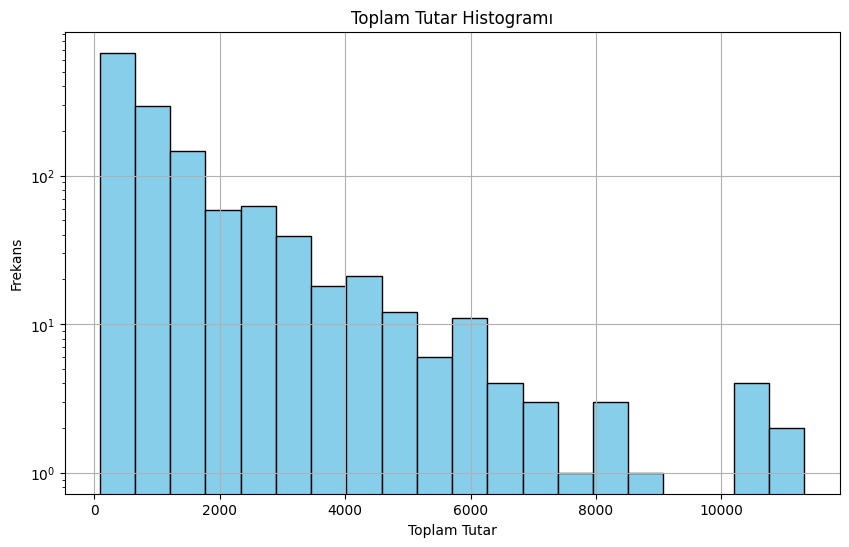

In [ ]:
import matplotlib.pyplot as plt

sinir = df['toplam_tutar'].quantile(0.99)

plt.figure(figsize=(10, 6))
plt.hist(df[df['toplam_tutar']<=sinir]['toplam_tutar'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Toplam Tutar')
plt.ylabel('Frekans')
plt.title('Toplam Tutar Histogramı')
plt.yscale('log')
plt.grid(True)
plt.show()

Müşteriler küçük ve orta ölçekli alışverişler yapma eğilimi göstermiştir, yüksek tutarlı uç harcamalar da az sayıda da olsa gerçekleşmiştir.

Sepet tutarı yükseldikçe sipariş oluşturma frekansı düşüş göstermektedir.

## 15. Aşağıdaki analizleri yapın: kategori sütunu için ``value_counts()`` çıktısını yazdırın, ``musteri_tipi`` sütunu için yüzde dağılımı hesaplayın, ``odeme_turu`` sütunu için count plot çizdirin, ``birim_fiyat``, ``toplam_tutar`` ve ``musteri_puani`` sütunlarının temel istatistiklerini çıkarın. Son olarak şu iki soruya cevap verin: Hangi kategori en yüksek ortalama ``toplam_tutar`` değerine sahip? Hangi müşteri tipi en yüksek ortalama ``musteri_puani`` değerine sahip?

In [ ]:
df['musteri_tipi'] = text_standardization(df['musteri_tipi'])

print(f"Kategori sütunu için verilerin miktarları:\n{df['kategori'].value_counts(dropna=False)}")
print("--------------------------------------------------")
print(f"Müşteri tipi sütunu için yüzde dağılımı:\n{df['musteri_tipi'].value_counts(normalize=True, dropna=False)*100}")
print("\n---------------Özet İstatistikler----------------")
print(f"Temel istatistikler:\n{df[['birim_fiyat','toplam_tutar','musteri_puani']].describe()}")



Kategori sütunu için verilerin miktarları:
kategori
kitap         250
elektronik    241
spor          231
ofis          222
kozmetik      217
ev&yasam      209
Name: count, dtype: int64
--------------------------------------------------
Müşteri tipi sütunu için yüzde dağılımı:
musteri_tipi
mevcut    51.021898
yeni      37.299270
vip       11.678832
Name: proportion, dtype: float64

---------------Özet İstatistikler----------------
Temel istatistikler:
        birim_fiyat  toplam_tutar  musteri_puani
count   1370.000000   1370.000000    1370.000000
mean     666.385241   1376.257423       3.989051
std     1060.030866   2973.808113       1.075267
min       93.110000     89.680000       0.000000
25%      199.365000    327.450000       4.000000
50%      287.120000    674.560000       4.000000
75%      824.807500   1399.225000       5.000000
max    18145.230000  63870.200000       5.000000


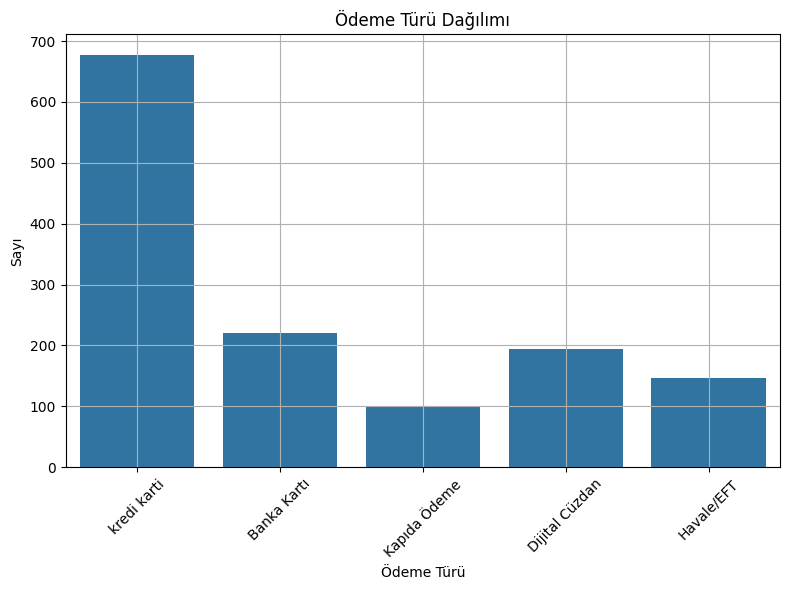

In [ ]:
import seaborn as sns

df['odeme_turu'] = text_standardization(df['odeme_turu'])
odeme_turu_harita = {
    "kredi kartı": "Kredi Kartı",
    "kart": "Kredi Kartı",
    "banka karti": "Banka Kartı",
    "banka kartı": "Banka Kartı",
    "dijital cuzdan": "Dijital Cüzdan",
    "havale/eft": "Havale/EFT",
    "havale": "Havale/EFT",
    "eft": "Havale/EFT",
    "kapida odeme": "Kapıda Ödeme"
}
df['odeme_turu'] = df['odeme_turu'].replace(odeme_turu_harita)

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='odeme_turu')
plt.xlabel('Ödeme Türü')
plt.ylabel('Sayı')
plt.title('Ödeme Türü Dağılımı')
# plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print("Hangi müşteri tipi en yüksek ortalama musteri_puani değerine sahip?")
round(df.groupby('musteri_tipi')['musteri_puani'].mean().sort_values(ascending=False),3)

Hangi müşteri tipi en yüksek ortalama musteri_puani değerine sahip?


,musteri_puani
musteri_tipi,
yeni,4.002
mevcut,4.000
vip,3.900


In [ ]:
print("Hangi kategori en yüksek ortalama toplam_tutar değerine sahip?")
df.groupby('kategori')['toplam_tutar'].mean().sort_values(ascending=False)

Hangi kategori en yüksek ortalama toplam_tutar değerine sahip?


,toplam_tutar
kategori,
elektronik,3178.379876
spor,1322.975844
ofis,1302.949865
kozmetik,916.341889
ev&yasam,868.099809
kitap,577.367120
